In [ ]:
# Montar Drive primero
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs("/content/drive/MyDrive/ECG_Proyecto", exist_ok=True)

# Descarga directa del ZIP (mucho más rápido)
!wget -O "/content/drive/MyDrive/ECG_Proyecto/ptb-xl.zip" \
  "https://physionet.org/static/published-projects/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip"

Mounted at /content/drive
--2026-03-23 15:26:43--  https://physionet.org/static/published-projects/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://physionet.org/content/ptb-xl/get-zip/1.0.3/ [following]
--2026-03-23 15:26:44--  https://physionet.org/content/ptb-xl/get-zip/1.0.3/
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 1839504686 (1.7G) [application/zip]
Saving to: ‘/content/drive/MyDrive/ECG_Proyecto/ptb-xl.zip’

/content/drive/MyDr 100%[===================>]   1.71G   201KB/s    in 2h 37m  

2026-03-23 18:04:03 (190 KB/s) - ‘/content/drive/MyDrive/ECG_Proyecto/ptb-xl.zip’ saved [1839504686/1839504686]



In [ ]:
import zipfile

print("Descomprimiendo... esto puede tardar unos minutos ⏳")

with zipfile.ZipFile("/content/drive/MyDrive/ECG_Proyecto/ptb-xl.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/drive/MyDrive/ECG_Proyecto/")

print("✅ Listo! Ya está descomprimido")

Descomprimiendo... esto puede tardar unos minutos ⏳
✅ Listo! Ya está descomprimido


In [ ]:
import os

ruta = "/content/drive/MyDrive/ECG_Proyecto"

for carpeta in os.listdir(ruta):
    print(carpeta)

ptb-xl.zip
ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3


In [ ]:
ruta_datos = "/content/drive/MyDrive/ECG_Proyecto/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"

for archivo in os.listdir(ruta_datos):
    print(archivo)

LICENSE.txt
RECORDS
SHA256SUMS.txt
example_physionet.py
ptbxl_database.csv
ptbxl_v102_changelog.txt
ptbxl_v103_changelog.txt
records100
records500
scp_statements.csv


In [ ]:
# Instalar librería para leer señales de ECG
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 47.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.


In [ ]:
import pandas as pd
import wfdb
import numpy as np
import matplotlib.pyplot as plt

# Cargar el CSV principal
ruta_datos = "/content/drive/MyDrive/ECG_Proyecto/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"

df = pd.read_csv(ruta_datos + "/ptbxl_database.csv", index_col='ecg_id')

print(f"Total de registros: {len(df)}")
print(f"\nColumnas disponibles:")
print(df.columns.tolist())

Total de registros: 21799

Columnas disponibles:
['patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human', 'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr']


In [ ]:
print("=== DISTRIBUCIÓN DE EDAD ===")
print(df['age'].describe())

print("\n=== DISTRIBUCIÓN DE SEXO ===")
print(df['sex'].value_counts())
print("(0 = Masculino, 1 = Femenino)")

print("\n=== DISTRIBUCIÓN DE FOLDS ===")
print(df['strat_fold'].value_counts().sort_index())

=== DISTRIBUCIÓN DE EDAD ===
count    21799.000000
mean        62.769301
std         32.308813
min          2.000000
25%         50.000000
50%         62.000000
75%         72.000000
max        300.000000
Name: age, dtype: float64

=== DISTRIBUCIÓN DE SEXO ===
sex
0    11354
1    10445
Name: count, dtype: int64
(0 = Masculino, 1 = Femenino)

=== DISTRIBUCIÓN DE FOLDS ===
strat_fold
1     2175
2     2181
3     2192
4     2174
5     2174
6     2173
7     2176
8     2173
9     2183
10    2198
Name: count, dtype: int64


In [ ]:
import ast

# Convertir la columna de etiquetas de texto a diccionario
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

# Cargar la tabla de diagnósticos
df_scp = pd.read_csv(ruta_datos + "/scp_statements.csv", index_col=0)

# Filtrar solo las superclases
df_scp_super = df_scp[df_scp['diagnostic_class'].notna()]

# Función para extraer la superclase de cada registro
def get_superclass(scp_dict):
    clases = []
    for code in scp_dict.keys():
        if code in df_scp_super.index:
            clases.append(df_scp_super.loc[code, 'diagnostic_class'])
    return list(set(clases))

df['superclasses'] = df['scp_codes'].apply(get_superclass)

# Contar cuántos registros tiene cada superclase
from collections import Counter
todas = [sc for lista in df['superclasses'] for sc in lista]
conteo = Counter(todas)

print("=== DISTRIBUCIÓN DE SUPERCLASES ===")
for clase, cantidad in sorted(conteo.items()):
    print(f"{clase}: {cantidad} registros")

=== DISTRIBUCIÓN DE SUPERCLASES ===
CD: 4898 registros
HYP: 2649 registros
MI: 5469 registros
NORM: 9514 registros
STTC: 5235 registros


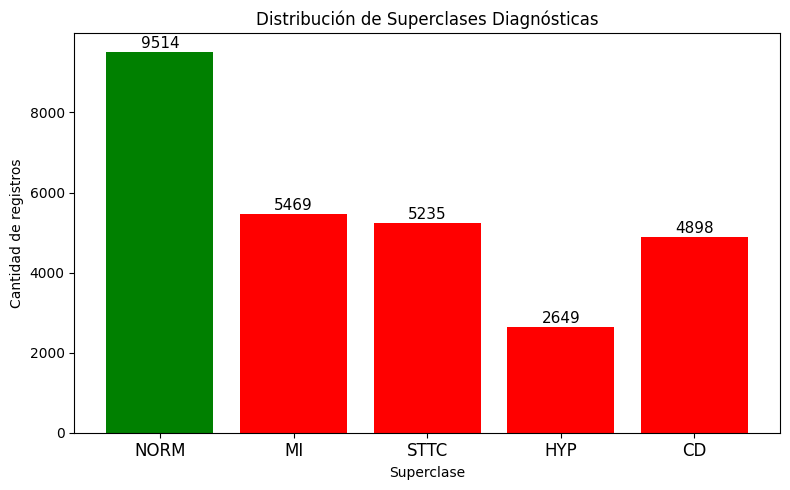

✅ Gráfica guardada en Drive


In [ ]:
import matplotlib.pyplot as plt

clases = list(conteo.keys())
cantidades = list(conteo.values())
colores = ['green', 'red', 'red', 'red', 'red']

plt.figure(figsize=(8,5))
plt.bar(clases, cantidades, color=colores)
plt.title('Distribución de Superclases Diagnósticas')
plt.xlabel('Superclase')
plt.ylabel('Cantidad de registros')
plt.xticks(fontsize=12)

for i, v in enumerate(cantidades):
    plt.text(i, v + 100, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ECG_Proyecto/distribucion_clases.png")
plt.show()

print("✅ Gráfica guardada en Drive")

In [ ]:
# Separar en train, validación y test según el documento
train = df[df['strat_fold'] <= 8]
val = df[df['strat_fold'] == 9]
test = df[df['strat_fold'] == 10]

print("=== TAMAÑO DE CADA SPLIT ===")
print(f"Entrenamiento (folds 1-8): {len(train)} registros")
print(f"Validación   (fold 9):     {len(val)} registros")
print(f"Test         (fold 10):    {len(test)} registros")

print("\n=== VERIFICACIÓN DE PACIENTES REPETIDOS ===")
pacientes_train = set(train['patient_id'])
pacientes_val = set(val['patient_id'])
pacientes_test = set(test['patient_id'])

overlap_val = pacientes_train & pacientes_val
overlap_test = pacientes_train & pacientes_test

print(f"Pacientes en train Y val:  {len(overlap_val)}")
print(f"Pacientes en train Y test: {len(overlap_test)}")

if len(overlap_val) == 0 and len(overlap_test) == 0:
    print("\n✅ Perfecto! No hay pacientes repetidos entre conjuntos")
else:
    print("\n⚠️ Hay pacientes repetidos, hay que revisar")

=== TAMAÑO DE CADA SPLIT ===
Entrenamiento (folds 1-8): 17418 registros
Validación   (fold 9):     2183 registros
Test         (fold 10):    2198 registros

=== VERIFICACIÓN DE PACIENTES REPETIDOS ===
Pacientes en train Y val:  0
Pacientes en train Y test: 0

✅ Perfecto! No hay pacientes repetidos entre conjuntos


In [ ]:
# Función para asignar etiqueta binaria
# NORM = 0 (Normal), cualquier otra cosa = 1 (Arritmia)
# Solo incluye etiquetas con likelihood >= 75%

def get_label(scp_dict):
    tiene_normal = False
    tiene_arritmia = False

    for code, likelihood in scp_dict.items():
        if likelihood >= 75:
            if code in df_scp_super.index:
                clase = df_scp_super.loc[code, 'diagnostic_class']
                if clase == 'NORM':
                    tiene_normal = True
                else:
                    tiene_arritmia = True

    if tiene_arritmia:
        return 1
    elif tiene_normal:
        return 0
    else:
        return None

df['label'] = df['scp_codes'].apply(get_label)

df_filtrado = df[df['label'].notna()].copy()
df_filtrado['label'] = df_filtrado['label'].astype(int)

print(f"Registros originales: {len(df)}")
print(f"Registros después del filtro: {len(df_filtrado)}")
print(f"Descartados: {len(df) - len(df_filtrado)}")

print("\n=== DISTRIBUCIÓN DE ETIQUETAS ===")
print(f"Normal   (0): {(df_filtrado['label'] == 0).sum()}")
print(f"Arritmia (1): {(df_filtrado['label'] == 1).sum()}")

Registros originales: 21799
Registros después del filtro: 19053
Descartados: 2746

=== DISTRIBUCIÓN DE ETIQUETAS ===
Normal   (0): 8610
Arritmia (1): 10443


In [ ]:
# Extraer señal DII de cada registro
ruta_datos = "/content/drive/MyDrive/ECG_Proyecto/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"

signals_list = []
labels_list = []
ids_list = []

total = len(df_filtrado)
print(f"Procesando {total} registros... esto puede tardar 20-30 minutos ⏳")

for i, (ecg_id, row) in enumerate(df_filtrado.iterrows()):
    try:
        # Leer el archivo de señal
        data, _ = wfdb.rdsamp(ruta_datos + "/" + row['filename_hr'])

        # Extraer solo la derivación DII (columna índice 1)
        dii = data[:, 1]

        signals_list.append(dii)
        labels_list.append(row['label'])
        ids_list.append(ecg_id)

        # Mostrar progreso cada 1000 registros
        if (i + 1) % 1000 == 0:
            print(f"  {i+1}/{total} registros procesados...")

    except Exception as e:
        print(f"Error en registro {ecg_id}: {e}")

print(f"\n✅ Listo! Se procesaron {len(signals_list)} señales")

Procesando 19053 registros... esto puede tardar 20-30 minutos ⏳
  1000/19053 registros procesados...
  2000/19053 registros procesados...
  3000/19053 registros procesados...
  4000/19053 registros procesados...
  5000/19053 registros procesados...
  6000/19053 registros procesados...
  7000/19053 registros procesados...
  8000/19053 registros procesados...
  9000/19053 registros procesados...
  10000/19053 registros procesados...
  11000/19053 registros procesados...
  12000/19053 registros procesados...
  13000/19053 registros procesados...
  14000/19053 registros procesados...
  15000/19053 registros procesados...
  16000/19053 registros procesados...
  17000/19053 registros procesados...
  18000/19053 registros procesados...
  19000/19053 registros procesados...

✅ Listo! Se procesaron 19053 señales


In [ ]:
import numpy as np

# Convertir a arrays de numpy
signals = np.array(signals_list)
labels = np.array(labels_list)

# Separar en train, val y test
df_filtrado_reset = df_filtrado.copy()
df_filtrado_reset['array_index'] = range(len(df_filtrado_reset))

train_idx = df_filtrado_reset[df_filtrado_reset['strat_fold'] <= 8]['array_index'].values
val_idx = df_filtrado_reset[df_filtrado_reset['strat_fold'] == 9]['array_index'].values
test_idx = df_filtrado_reset[df_filtrado_reset['strat_fold'] == 10]['array_index'].values

# Guardar archivos .npy
ruta_salida = "/content/drive/MyDrive/ECG_Proyecto"

np.save(f"{ruta_salida}/train_signals.npy", signals[train_idx])
np.save(f"{ruta_salida}/val_signals.npy", signals[val_idx])
np.save(f"{ruta_salida}/test_signals.npy", signals[test_idx])

print("✅ Archivos .npy guardados!")
print(f"  train_signals.npy: {len(train_idx)} señales")
print(f"  val_signals.npy:   {len(val_idx)} señales")
print(f"  test_signals.npy:  {len(test_idx)} señales")

✅ Archivos .npy guardados!
  train_signals.npy: 15258 señales
  val_signals.npy:   1890 señales
  test_signals.npy:  1905 señales


In [ ]:
# Crear el CSV de etiquetas
registros = []

for idx in df_filtrado_reset.index:
    row = df_filtrado_reset.loc[idx]
    array_idx = row['array_index']

    if array_idx in train_idx:
        split = 'train'
    elif array_idx in val_idx:
        split = 'val'
    else:
        split = 'test'

    registros.append({
        'record_id': idx,
        'fold': row['strat_fold'],
        'label': row['label'],
        'split': split
    })

df_labels = pd.DataFrame(registros)
df_labels.to_csv(f"{ruta_salida}/labels.csv", index=False)

print("✅ CSV de etiquetas guardado!")
print(f"\n=== ESTADÍSTICAS FINALES ===")
for split in ['train', 'val', 'test']:
    subset = df_labels[df_labels['split'] == split]
    normales = (subset['label'] == 0).sum()
    arritmias = (subset['label'] == 1).sum()
    print(f"\n{split.upper()}:")
    print(f"  Normal   (0): {normales}")
    print(f"  Arritmia (1): {arritmias}")

✅ CSV de etiquetas guardado!

=== ESTADÍSTICAS FINALES ===

TRAIN:
  Normal   (0): 6895
  Arritmia (1): 8363

VAL:
  Normal   (0): 852
  Arritmia (1): 1038

TEST:
  Normal   (0): 863
  Arritmia (1): 1042


In [ ]:
import os

ruta_salida = "/content/drive/MyDrive/ECG_Proyecto"

print("Archivos en ECG_Proyecto:")
for archivo in os.listdir(ruta_salida):
    print(f"  {archivo}")

Archivos en ECG_Proyecto:
  ptb-xl.zip
  ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3
  distribucion_clases.png
  train_signals.npy
  val_signals.npy
  test_signals.npy
  labels.csv


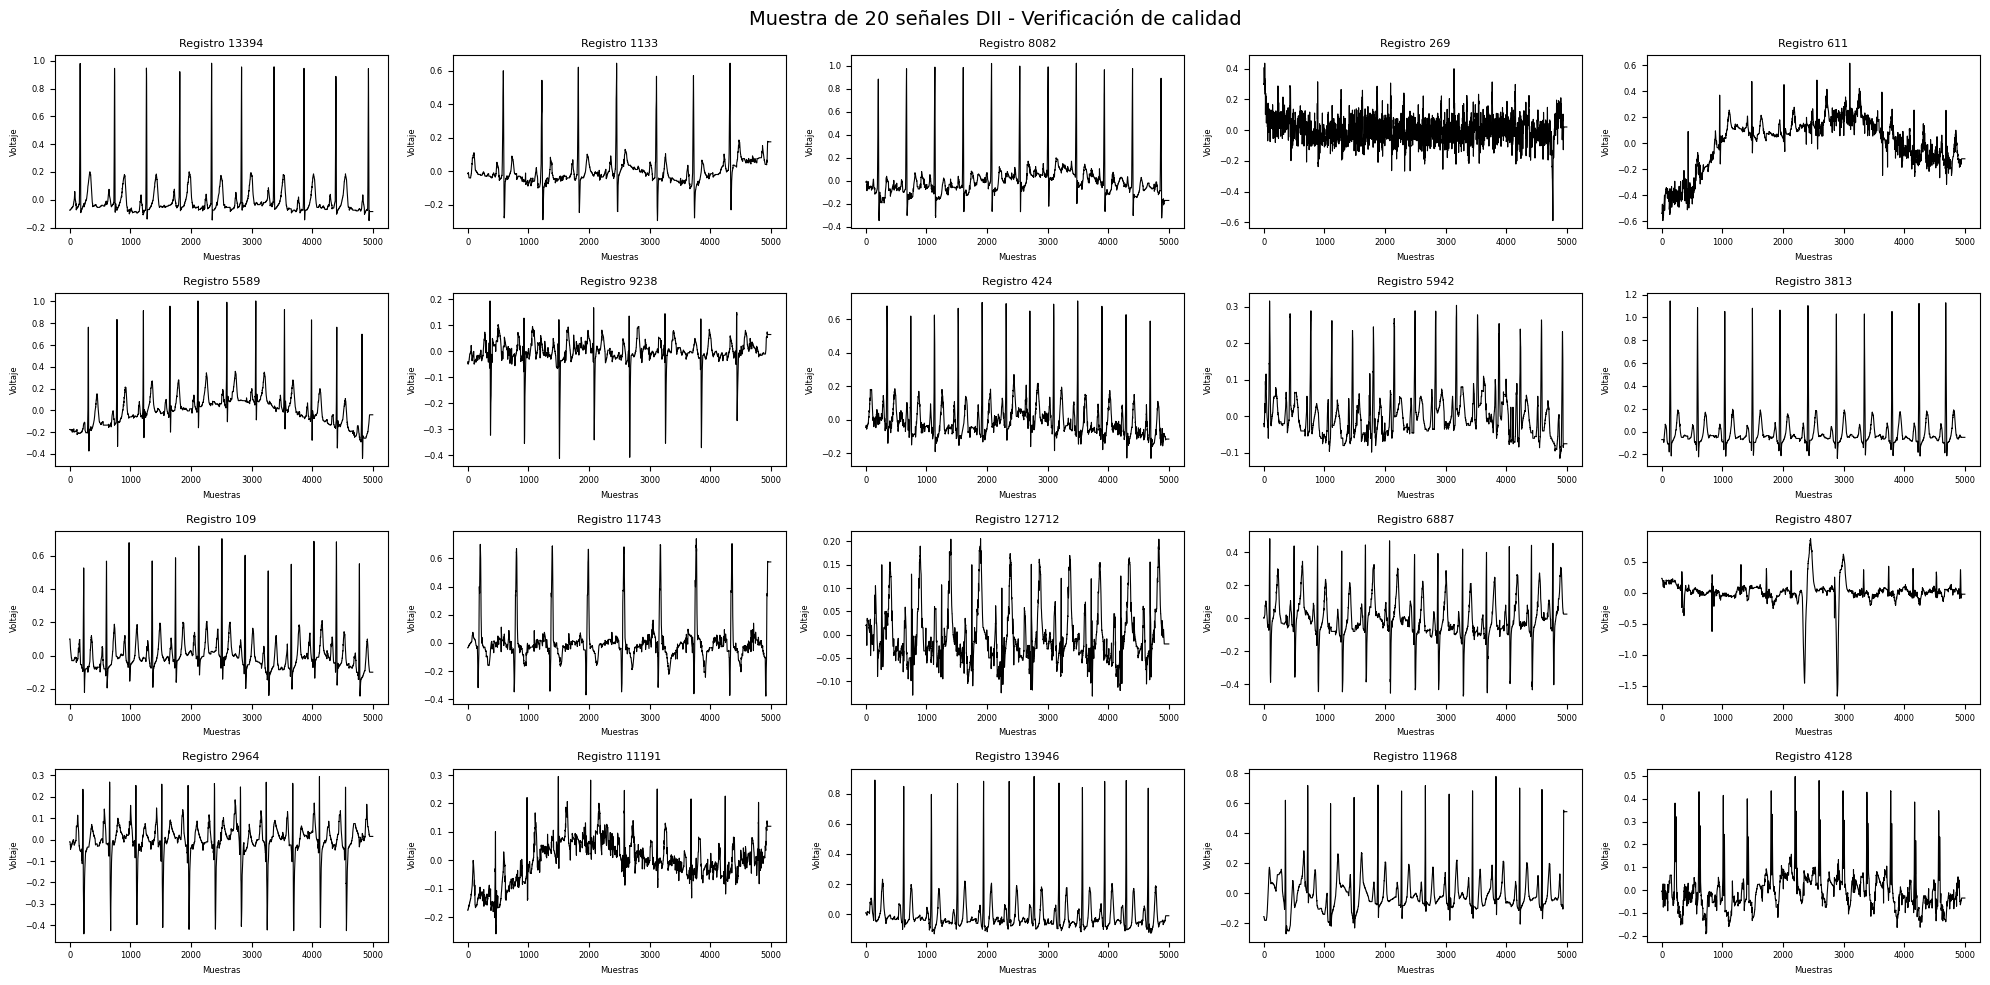

✅ Gráfica de verificación guardada en Drive


In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Cargar las señales
train_signals = np.load(f"{ruta_salida}/train_signals.npy")

# Seleccionar 20 registros al azar
indices = random.sample(range(len(train_signals)), 20)

# Graficar
fig, axes = plt.subplots(4, 5, figsize=(20, 10))
axes = axes.flatten()

for i, idx in enumerate(indices):
    axes[i].plot(train_signals[idx], linewidth=0.8, color='black')
    axes[i].set_title(f"Registro {idx}", fontsize=8)
    axes[i].set_xlabel("Muestras", fontsize=6)
    axes[i].set_ylabel("Voltaje", fontsize=6)
    axes[i].tick_params(labelsize=6)

plt.suptitle("Muestra de 20 señales DII - Verificación de calidad", fontsize=14)
plt.tight_layout()
plt.savefig(f"{ruta_salida}/verificacion_calidad.png")
plt.show()

print("✅ Gráfica de verificación guardada en Drive")

In [ ]:
# Verificar señales problemáticas
print("Buscando señales problemáticas...")

señales_planas = []
señales_ruidosas = []

for i, signal in enumerate(train_signals):
    std = np.std(signal)

    # Señal plana = casi sin variación
    if std < 0.01:
        señales_planas.append(i)

    # Señal ruidosa = variación extremadamente alta
    if std > 5:
        señales_ruidosas.append(i)

print(f"Señales planas encontradas:   {len(señales_planas)}")
print(f"Señales ruidosas encontradas: {len(señales_ruidosas)}")

if len(señales_planas) == 0 and len(señales_ruidosas) == 0:
    print("\n✅ Todas las señales se ven bien, sin problemas detectados")
else:
    print("\n⚠️ Hay señales problemáticas, hay que revisarlas")

Buscando señales problemáticas...
Señales planas encontradas:   0
Señales ruidosas encontradas: 0

✅ Todas las señales se ven bien, sin problemas detectados
